# Spacecraft Attitude Control with RL and CBFs

This notebook sets up a time-optimal attitude slewing maneuver using Reinforcement Learning (RL), specifically Soft Actor-Critic (SAC), while enforcing strict keep-out zones using Control Barrier Functions (CBFs).

### References:
1. **Rigid Body Dynamics**: Hughes, P. C. (2004). *Spacecraft attitude dynamics*.
2. **Control Barrier Functions**: Ames, A. D., et al. (2019). *Control Barrier Functions: Theory and Applications*.
3. **Reinforcement Learning**:  Haarnoja, Tuomas, et al. (2018) *Soft actor-critic: Off-policy maximum entropy deep reinforcement learning with a stochastic actor.*
4. **Gaussian Process-based safety filter**: Choi, Jason J., et al. (2025) *Constraint-guided online data selection for scalable data-driven safety filters in uncertain robotic systems.*
5. **CBF-RL**: Yang, et al. (2026). *CBF-RL: Safety Filtering Reinforcement Learning in Training with Control Barrier Functions*.
6. **Software**:
   - [Stable-Baselines3](https://stable-baselines3.readthedocs.io/)
   - [Gymnasium](https://gymnasium.farama.org/)
   - [CVXPY](https://www.cvxpy.org/)

In [1]:
!pip install gymnasium stable-baselines3 cvxpy

## 1 & 2. Base Control Strategy (SAC) and Safety Assurance (HOCBF)

This section defines the fundamental spacecraft attitude dynamics and implements the original analytical High-Order Control Barrier Function (HOCBF) to enforce safety constraints (e.g., sensitive instrument keep-out zones) during the Reinforcement Learning control.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import os
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import gymnasium as gym
from gymnasium import spaces
import cvxpy as cp

from stable_baselines3 import SAC, PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.results_plotter import load_results, ts2xy
from stable_baselines3.common.callbacks import BaseCallback
from stable_baselines3.common.buffers import RolloutBuffer

from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel

from google.colab import drive, files

def quat_multiply(q1, q2):
    # Quaternion multiplication (scalar last)
    x1, y1, z1, w1 = q1
    x2, y2, z2, w2 = q2
    return np.array([
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2,
        w1*w2 - x1*x2 - y1*y2 - z1*z2
    ])

def quat_to_rotmat(q):
    # Quaternion to Body-to-Inertial rotation matrix (scalar last)
    x, y, z, w = q
    return np.array([
        [1 - 2*(y**2 + z**2), 2*(x*y - z*w),     2*(x*z + y*w)],
        [2*(x*y + z*w),     1 - 2*(x**2 + z**2), 2*(y*z - x*w)],
        [2*(x*z - y*w),     2*(y*z + x*w),     1 - 2*(x**2 + y**2)]
    ])

class SpacecraftAttitudeEnv(gym.Env):
    """
    Custom Environment that follows gym interface for Spacecraft Attitude Control.
    State: [q1, q2, q3, q4, w1, w2, w3] (quaternion and angular velocity)
    Action: [tx, ty, tz] (control torques)
    """
    metadata = {'render_modes': ['console']}

    def __init__(self):
        super(SpacecraftAttitudeEnv, self).__init__()
        # Action space: Torque in x, y, z axes
        self.action_space = spaces.Box(low=-1.0, high=1.0, shape=(3,), dtype=np.float32)
        # Observation space: Quaternion (4) + Angular Velocity (3)
        self.observation_space = spaces.Box(low=-np.inf, high=np.inf, shape=(7,), dtype=np.float32)

        # Spacecraft properties
        self.inertia_matrix = np.diag([10.0, 15.0, 20.0])
        self.inv_inertia = np.linalg.inv(self.inertia_matrix)
        self.dt = 0.05

        # Keep-out zone (e.g., Sun vector in inertial frame)
        self.sun_vector_inertial = np.array([1.0, 0.0, 0.0])
        self.sensitive_axis_body = np.array([0.0, 0.0, 1.0])
        self.keep_out_angle_cos = np.cos(np.deg2rad(30)) # 30 degrees keep-out

    def step(self, action):
        # 1. Apply High-Order CBF Safety Filter to the proposed RL action
        safe_action = self.apply_cbf_filter(self.state, action)

        # 2. Extract state
        q = self.state[:4]
        w = self.state[4:]

        # 3. Dynamics (Euler equations for rigid body)
        # dw/dt = I^-1 * (torque - w x (I * w))
        torque = safe_action * 0.5 # Scale max torque
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))

        # dq/dt = 0.5 * q * [w, 0]
        w_quat = np.append(w, 0.0)
        dq_dt = 0.5 * quat_multiply(q, w_quat)

        # 4. Euler Integration
        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next) # Normalize quaternion

        self.state = np.concatenate([q_next, w_next])

        # 5. Reward Calculation
        # Target is origin (q = [0, 0, 0, 1], w = [0, 0, 0])
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(safe_action)

        # Check termination
        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated:
            reward += 100.0

        # Truncation if it spins out of control
        truncated = bool(np.linalg.norm(w_next) > 5.0)

        return self.state.astype(np.float32), reward, terminated, truncated, {}

    def apply_cbf_filter(self, state, nominal_action):
        """
        High-Order Control Barrier Function for precise attitude safety.
        Ensures the angle between sensitive axis and sun vector >= theta_min.
        Because torque -> angular acceleration -> angular velocity -> attitude,
        the system has a relative degree of 2.
        """
        q = state[:4]
        w = state[4:]

        # Rotation matrix from Body to Inertial
        R_B_I = quat_to_rotmat(q)
        # Sun vector transformed into the Body frame
        v_s_B = R_B_I.T @ self.sun_vector_inertial
        v_sens = self.sensitive_axis_body

        # Normal vector for Lie derivative calculations
        n = np.cross(v_s_B, v_sens)

        # Level 0 CBF: h0(x) >= 0 is the safe set
        h0 = self.keep_out_angle_cos - np.dot(v_s_B, v_sens)
        h0_dot = np.dot(w, n)

        # Level 1 CBF: h1(x) = h0_dot + lambda * h0 >= 0
        lambda_val = 5.0
        h1 = h0_dot + lambda_val * h0

        # Calculate exact Lie Derivatives for h1(x)
        v_s_B_dot = np.cross(-w, v_s_B)
        n_dot = np.cross(v_s_B_dot, v_sens)

        # Lg_h1 (Coefficient of the control input u)
        # Scaled by 0.5 because actual torque in step() is u * 0.5
        Lg_h1 = (self.inv_inertia @ n) * 0.5

        # Lf_h1 (Drift component)
        cross_Iw = np.cross(w, self.inertia_matrix @ w)
        Lf_h1 = -np.dot(self.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

        gamma = 5.0

        u = cp.Variable(3)
        u_nom = nominal_action

        # Solve QP to find the closest safe action
        objective = cp.Minimize(cp.sum_squares(u - u_nom))
        constraints = [Lg_h1 @ u + Lf_h1 + gamma * h1 >= 0,
                       u >= -1.0, u <= 1.0]

        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP)
            if u.value is not None:
                return u.value
            return nominal_action
        except:
            return nominal_action

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        # Initialize randomly but safely away from keep-out
        q = np.random.randn(4)
        q = q / np.linalg.norm(q)
        w = np.random.randn(3) * 0.1
        self.state = np.concatenate([q, w])
        return self.state.astype(np.float32), {}

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## 3. Integration of Safety in Training (CBF-RL)

To prevent the agent from constantly fighting the safety filter, we modify the environment to penalize the RL agent proportionally to the magnitude of the CBF's intervention. This teaches the agent to proactively avoid the keep-out zone.

In [3]:
class CBFRL_SpacecraftAttitudeEnv(SpacecraftAttitudeEnv):
    """
    Environment modified to incorporate CBF-RL methodology.
    The RL agent receives a penalty proportional to the CBF intervention.
    """
    def __init__(self):
        super().__init__()

    def step(self, action):
        # 1. Apply High-Order CBF Safety Filter
        safe_action = self.apply_cbf_filter(self.state, action)

        # 2. Calculate CBF intervention (difference between nominal and safe action)
        # This acts as a differentiable-like feedback signal to the RL agent.
        intervention_penalty = np.linalg.norm(safe_action - action)

        # 3. Extract state and apply dynamics
        q = self.state[:4]
        w = self.state[4:]

        torque = safe_action * 0.5
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))

        w_quat = np.append(w, 0.0)
        dq_dt = 0.5 * quat_multiply(q, w_quat)

        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next)

        self.state = np.concatenate([q_next, w_next])

        # 4. Reward Calculation - Now incorporating the CBF intervention penalty
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2

        # Reward: progress to target, minimize energy, AND minimize CBF intervention
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(safe_action) - 50.0 * intervention_penalty

        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated:
            reward += 100.0

        truncated = bool(np.linalg.norm(w_next) > 5.0)

        return self.state.astype(np.float32), reward, terminated, truncated, {}

# Initialize the new CBF-RL environment
cbf_rl_env = CBFRL_SpacecraftAttitudeEnv()

print("CBF-RL Environment Initialized. Ready for training with intervention penalties.")

CBF-RL Environment Initialized. Ready for training with intervention penalties.


In [4]:
# Initialize Environment and Train RL Agent
env = CBFRL_SpacecraftAttitudeEnv()

print("Initializing SAC Agent...")
model = SAC("MlpPolicy", env, verbose=1)

print("Training for 30,000 timesteps to match baseline comparisons...")
model.learn(total_timesteps=30000)

print("Training complete.")

Initializing SAC Agent...
Using cuda device
Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.
Training for 30,000 timesteps to match baseline comparisons...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Training complete.


In [5]:
# Save the trained SAC model
model_path = "cbf_rl_sac_spacecraft_attitude_model"
model.save(model_path)
print(f"Model saved to {model_path}.zip")

# To load the model later in another session, you can use:
# loaded_model = SAC.load(model_path)


Model saved to cbf_rl_sac_spacecraft_attitude_model.zip


In [6]:
# Evaluate the trained SAC Agent
obs, info = env.reset(seed=42)
terminated = False
truncated = False
total_reward = 0.0
steps = 0
max_test_steps = 10000 # Added to prevent infinite loops during testing

# Lists to store trajectory data for potential visualization
states = [obs]
actions = []

print("Starting test episode...")
while not (terminated or truncated) and steps < max_test_steps:
    # Use deterministic=True for evaluation
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env.step(action)

    states.append(obs)
    actions.append(action)
    total_reward += reward
    steps += 1

states = np.array(states)
actions = np.array(actions)

print(f"Test episode finished in {steps} steps.")
if steps == max_test_steps:
    print("Episode stopped due to max steps limit (agent did not perfectly reach the target).")
print(f"Total Reward: {total_reward:.2f}")
print(f"Final State (Quaternion): {states[-1, :4]}")
print(f"Final State (Angular Velocity): {states[-1, 4:]}")

Starting test episode...
Test episode finished in 10000 steps.
Episode stopped due to max steps limit (agent did not perfectly reach the target).
Total Reward: -7835.60
Final State (Quaternion): [ 0.5958115   0.28148532  0.5604356  -0.5016838 ]
Final State (Angular Velocity): [-0.31260905 -0.35958105  0.9262539 ]


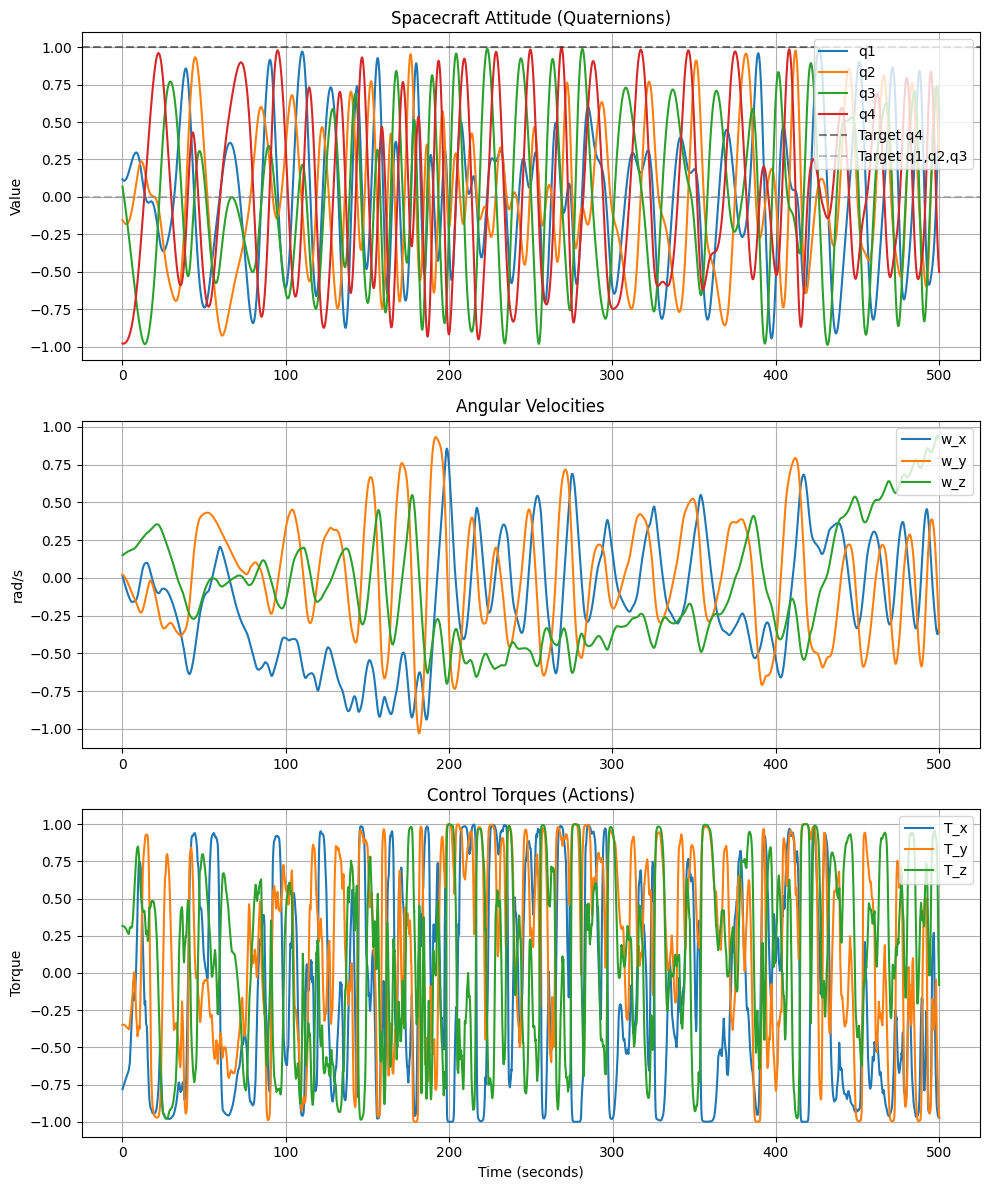

In [7]:
# Calculate time array based on dt
time_steps = np.arange(len(states)) * env.dt
time_steps_actions = np.arange(len(actions)) * env.dt

fig, axs = plt.subplots(3, 1, figsize=(10, 12))

# 1. Plot Quaternions
axs[0].plot(time_steps, states[:, 0], label='q1')
axs[0].plot(time_steps, states[:, 1], label='q2')
axs[0].plot(time_steps, states[:, 2], label='q3')
axs[0].plot(time_steps, states[:, 3], label='q4')
axs[0].axhline(y=1.0, color='k', linestyle='--', alpha=0.5, label='Target q4')
axs[0].axhline(y=0.0, color='gray', linestyle='--', alpha=0.5, label='Target q1,q2,q3')
axs[0].set_title('Spacecraft Attitude (Quaternions)')
axs[0].set_ylabel('Value')
axs[0].legend(loc='upper right')
axs[0].grid(True)

# 2. Plot Angular Velocities
axs[1].plot(time_steps, states[:, 4], label='w_x')
axs[1].plot(time_steps, states[:, 5], label='w_y')
axs[1].plot(time_steps, states[:, 6], label='w_z')
axs[1].set_title('Angular Velocities')
axs[1].set_ylabel('rad/s')
axs[1].legend(loc='upper right')
axs[1].grid(True)

# 3. Plot Actions (Torques)
axs[2].plot(time_steps_actions, actions[:, 0], label='T_x')
axs[2].plot(time_steps_actions, actions[:, 1], label='T_y')
axs[2].plot(time_steps_actions, actions[:, 2], label='T_z')
axs[2].set_title('Control Torques (Actions)')
axs[2].set_xlabel('Time (seconds)')
axs[2].set_ylabel('Torque')
axs[2].legend(loc='upper right')
axs[2].grid(True)

plt.tight_layout()
plt.show()


### Prototype: Gaussian Process Data-Driven HOCBF
This class demonstrates how to use `scikit-learn` to approximate the unmodeled dynamics (the drift term $L_f h_1$) and use the GP's uncertainty bound to tighten the safety constraint.

In [8]:
class DataDrivenGPHOCBF:
    def __init__(self):
        # Define GP kernel: Matern-5/2 for realistic smoothness + WhiteKernel for measurement noise
        kernel = 1.0 * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-4)
        self.gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=5)
        self.is_trained = False

    def train_gp(self, X_states, y_lfh_residuals):
        """
        Train the GP on collected offline or online data.
        X_states: shape (N, 7) - The states of the spacecraft
        y_lfh_residuals: shape (N,) - The unmodeled effect on Lf_h1 observed in data
        """
        print("Training Gaussian Process on safety data...")
        self.gp.fit(X_states, y_lfh_residuals)
        self.is_trained = True
        print(f"GP Training complete. R^2 Score: {self.gp.score(X_states, y_lfh_residuals):.4f}")

    def get_gp_prediction(self, state):
        """
        Returns the predicted mean and standard deviation (uncertainty) for a given state.
        """
        if not self.is_trained:
            return 0.0, 0.0

        # Reshape state for sklearn
        mean_res, std_res = self.gp.predict(state.reshape(1, -1), return_std=True)
        return mean_res[0], std_res[0]

    def filter_action(self, state, nominal_action, Lf_h1_nom, Lg_h1, h1, gamma=5.0, confidence_beta=2.0):
        """
        The GP-CBF safety filter.
        confidence_beta controls how conservative the filter is based on GP uncertainty.
        """
        u = cp.Variable(3)
        u_nom = nominal_action

        # 1. Get GP prediction for unmodeled dynamics and the uncertainty bound
        gp_mean, gp_std = self.get_gp_prediction(state)

        # 2. Formulate the robust GP-CBF Constraint:
        # Lg_h1 * u + (Lf_h1_nom + gp_mean) - confidence_beta * gp_std + gamma * h1 >= 0
        # Notice we SUBTRACT (beta * std) to tighten the constraint when uncertain!
        drift_term = Lf_h1_nom + gp_mean - (confidence_beta * gp_std)

        # 3. Solve QP
        objective = cp.Minimize(cp.sum_squares(u - u_nom))
        constraints = [Lg_h1 @ u + drift_term + gamma * h1 >= 0,
                       u >= -1.0, u <= 1.0]

        prob = cp.Problem(objective, constraints)
        try:
            prob.solve(solver=cp.OSQP)
            if u.value is not None:
                return u.value
            return nominal_action
        except:
            return nominal_action

print("GP-HOCBF Prototype loaded successfully.")
# To use this: Collect data (states and Lf_h1 errors), call .train_gp(),
# and then replace your env's QP formulation with .filter_action().

GP-HOCBF Prototype loaded successfully.


## 4 & 5. Robustness to Unmodeled Dynamics and Data Efficiency (GP-HOCBF & Active Learning)

When the analytical model doesn't match reality, safety guarantees are lost. Here we augment the HOCBF with a Gaussian Process (GP) to learn unmodeled dynamics. To keep the GP computationally tractable, we implement an online data selector (Active Learning) to maintain a coreset of the most critical boundary-defining states.

In [9]:
print("Initializing GP-HOCBF and starting Active Learning (Uncertainty Sampling)...")
gp_cbf = DataDrivenGPHOCBF()
env_sim = CBFRL_SpacecraftAttitudeEnv()

# 1. Create a large candidate pool of states, emphasizing the KOZ boundary
N_pool = 1000
X_pool = []
y_pool = []

def get_unmodeled_dynamics(state):
    # Simulated unmodeled dynamics (e.g., aerodynamic drag, magnetic disturbances)
    return 0.02 * np.sin(state[4] * 5.0) + 0.01 * np.cos(state[0] * 3.0)

for _ in range(N_pool):
    q = np.random.randn(4)
    q = q / np.linalg.norm(q)
    w = np.random.randn(3) * 0.5
    state = np.concatenate([q, w])

    # Check angle to sun
    R_B_I = quat_to_rotmat(q)
    v_s_B = R_B_I.T @ env_sim.sun_vector_inertial
    angle_cos = np.dot(v_s_B, env_sim.sensitive_axis_body)

    # Bias pool towards the boundary (keep_out_angle_cos is ~0.866)
    if np.random.rand() < 0.7 and abs(angle_cos - env_sim.keep_out_angle_cos) > 0.1:
        continue # Skip some states that are far from boundary to concentrate data

    X_pool.append(state)
    y_pool.append(get_unmodeled_dynamics(state))

X_pool = np.array(X_pool)
y_pool = np.array(y_pool)

# 2. Initial Training Set (Randomly select a few points to bootstrap)
initial_idx = np.random.choice(len(X_pool), 10, replace=False)
X_train = X_pool[initial_idx].tolist()
y_train = y_pool[initial_idx].tolist()

# Remove initial points from pool
X_pool = np.delete(X_pool, initial_idx, axis=0)
y_pool = np.delete(y_pool, initial_idx, axis=0)

# Train initially (suppress output for cleaner logs)
old_stdout = sys.stdout
sys.stdout = open(os.devnull, 'w')
gp_cbf.train_gp(np.array(X_train), np.array(y_train))
sys.stdout = old_stdout

# 3. Active Learning Loop
n_al_iterations = 20
samples_per_iter = 5

for i in range(n_al_iterations):
    # Evaluate uncertainty on the pool
    _, stds = gp_cbf.gp.predict(X_pool, return_std=True)

    # Select points with maximum uncertainty
    best_idx = np.argsort(stds)[-samples_per_iter:]

    # Add to training set
    X_train.extend(X_pool[best_idx])
    y_train.extend(y_pool[best_idx])

    # Remove from pool
    X_pool = np.delete(X_pool, best_idx, axis=0)
    y_pool = np.delete(y_pool, best_idx, axis=0)

    # Retrain GP
    sys.stdout = open(os.devnull, 'w')
    gp_cbf.train_gp(np.array(X_train), np.array(y_train))
    sys.stdout = old_stdout

print(f"Active Learning complete. GP trained on {len(X_train)} strategically selected samples.")

# --- Proceed with the Performance Comparison Test ---
# Set up a test state and nominal action
env_test = CBFRL_SpacecraftAttitudeEnv()
state_test = env_test.reset(seed=42)[0]
nominal_action_test = np.array([0.5, -0.2, 0.1])

# Extract nominal dynamics components for the GP filter test
q = state_test[:4]
w = state_test[4:]
R_B_I = quat_to_rotmat(q)
v_s_B = R_B_I.T @ env_test.sun_vector_inertial
v_sens = env_test.sensitive_axis_body
n = np.cross(v_s_B, v_sens)
h0 = env_test.keep_out_angle_cos - np.dot(v_s_B, v_sens)
h0_dot = np.dot(w, n)
lambda_val = 5.0
h1 = h0_dot + lambda_val * h0
v_s_B_dot = np.cross(-w, v_s_B)
n_dot = np.cross(v_s_B_dot, v_sens)
Lg_h1 = (env_test.inv_inertia @ n) * 0.5
cross_Iw = np.cross(w, env_test.inertia_matrix @ w)
Lf_h1_nom = -np.dot(env_test.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

n_iterations = 100

# 1. Profile Original QP Solver
start_time = time.time()
for _ in range(n_iterations):
    _ = env_test.apply_cbf_filter(state_test, nominal_action_test)
orig_time = (time.time() - start_time) / n_iterations

# 2. Profile GP-Based QP Solver
start_time = time.time()
for _ in range(n_iterations):
    _ = gp_cbf.filter_action(state_test, nominal_action_test, Lf_h1_nom, Lg_h1, h1)
gp_time = (time.time() - start_time) / n_iterations

print(f"\n--- Performance Comparison over {n_iterations} iterations ---")
print(f"Original QP Solver:   {orig_time*1000:.3f} ms per step")
print(f"GP-Based CBF Filter:  {gp_time*1000:.3f} ms per step")

Initializing GP-HOCBF and starting Active Learning (Uncertainty Sampling)...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Active Learning complete. GP trained on 110 strategically selected samples.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



--- Performance Comparison over 100 iterations ---
Original QP Solver:   7.046 ms per step
GP-Based CBF Filter:  6.891 ms per step


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [10]:
class OnlineGPDataSelector:
    def __init__(self, max_coreset_size=200, retrain_freq=50):
        self.max_coreset_size = max_coreset_size
        self.retrain_freq = retrain_freq
        self.coreset_X = []
        self.coreset_y = []
        self.step_counter = 0

        kernel = 1.0 * Matern(length_scale=1.0, nu=2.5) + WhiteKernel(noise_level=1e-4)
        self.gp = GaussianProcessRegressor(kernel=kernel, n_restarts_optimizer=1)
        self.is_trained = False

    def acquisition_function(self, state, env):
        # 1. Check if near the Keep-Out Zone boundary
        q = state[:4]
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ env.sun_vector_inertial
        angle_cos = np.dot(v_s_B, env.sensitive_axis_body)

        # Boundary is around keep_out_angle_cos (0.866)
        distance_to_boundary = abs(angle_cos - env.keep_out_angle_cos)

        # 2. Check GP Uncertainty (proxy for BALD/Information Gain)
        if not self.is_trained:
            uncertainty = 1.0 # High uncertainty if untrained
        else:
            _, std = self.gp.predict(state.reshape(1, -1), return_std=True)
            uncertainty = std[0]

        # Score: Higher if close to boundary AND highly uncertain
        # We use a Gaussian-like weighting for boundary proximity
        boundary_weight = np.exp(-(distance_to_boundary**2) / 0.05)
        score = boundary_weight * uncertainty

        return score

    def process_step(self, state, unmodeled_error, env):
        self.step_counter += 1

        # Evaluate acquisition score
        score = self.acquisition_function(state, env)

        # Threshold for adding to coreset (can be dynamic, using a fixed one for simplicity)
        if score > 0.1 or len(self.coreset_X) < 10:
            if len(self.coreset_X) >= self.max_coreset_size:
                # If full, remove the oldest or least informative (here removing oldest for simplicity)
                self.coreset_X.pop(0)
                self.coreset_y.pop(0)

            self.coreset_X.append(state)
            self.coreset_y.append(unmodeled_error)

        # Retrain GP periodically if we have enough data
        if self.step_counter % self.retrain_freq == 0 and len(self.coreset_X) >= 10:
            old_stdout = sys.stdout
            sys.stdout = open(os.devnull, 'w')
            self.gp.fit(np.array(self.coreset_X), np.array(self.coreset_y))
            sys.stdout = old_stdout
            self.is_trained = True

print("Online GP Data Selector initialized.")

# --- Demonstrate Online Data Selection ---
print("Starting online simulation loop with original HOCBF and online data selection...")
online_selector = OnlineGPDataSelector(max_coreset_size=150, retrain_freq=100)
online_env = CBFRL_SpacecraftAttitudeEnv()

obs, _ = online_env.reset(seed=37)
terminated = False
truncated = False
online_steps = 0

# Simulated online loop (e.g., during a deployment or parallel training run)
while not (terminated or truncated) and online_steps < 2000:
    # Use nominal RL policy
    action, _ = model.predict(obs, deterministic=True)

    # The environment step applies the original HOCBF
    next_obs, reward, terminated, truncated, _ = online_env.step(action)

    # Simulate observing the unmodeled dynamics error (e.g., via state derivative mismatch)
    unmodeled_error = get_unmodeled_dynamics(obs)

    # Online Data Selection process
    online_selector.process_step(obs, unmodeled_error, online_env)

    obs = next_obs
    online_steps += 1

print(f"Online simulation complete after {online_steps} steps.")
print(f"Final Coreset Size: {len(online_selector.coreset_X)} strategically selected samples near the KOZ boundary.")

Online GP Data Selector initialized.
Starting online simulation loop with original HOCBF and online data selection...
Online simulation complete after 2000 steps.
Final Coreset Size: 100 strategically selected samples near the KOZ boundary.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


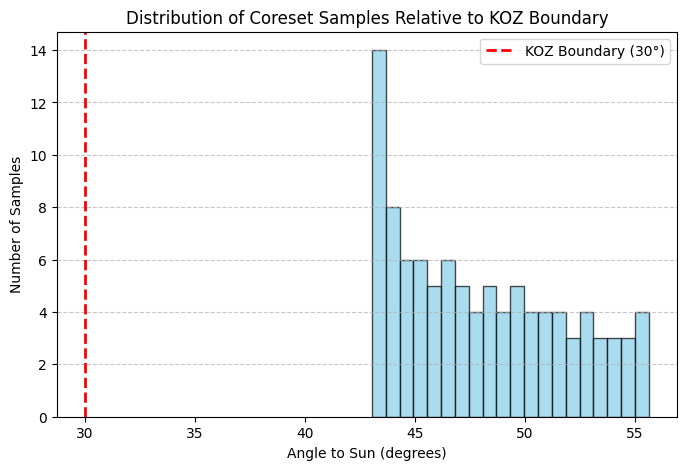

Total samples in coreset: 100
Minimum angle in coreset: 43.04°
Maximum angle in coreset: 55.63°


In [11]:
import matplotlib.pyplot as plt
import numpy as np

if not online_selector.coreset_X:
    print("Coreset is empty! The agent might not have encountered high-uncertainty states near the boundary.")
else:
    coreset_angles = []
    for state in online_selector.coreset_X:
        q = state[:4]
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ online_env.sun_vector_inertial
        angle_cos = np.clip(np.dot(v_s_B, online_env.sensitive_axis_body), -1.0, 1.0)
        angle_deg = np.rad2deg(np.arccos(angle_cos))
        coreset_angles.append(angle_deg)

    plt.figure(figsize=(8, 5))
    plt.hist(coreset_angles, bins=20, color='skyblue', edgecolor='black', alpha=0.7)
    plt.axvline(x=30.0, color='red', linestyle='--', linewidth=2, label='KOZ Boundary (30°)')
    plt.title('Distribution of Coreset Samples Relative to KOZ Boundary')
    plt.xlabel('Angle to Sun (degrees)')
    plt.ylabel('Number of Samples')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

    print(f"Total samples in coreset: {len(online_selector.coreset_X)}")
    print(f"Minimum angle in coreset: {min(coreset_angles):.2f}°")
    print(f"Maximum angle in coreset: {max(coreset_angles):.2f}°")


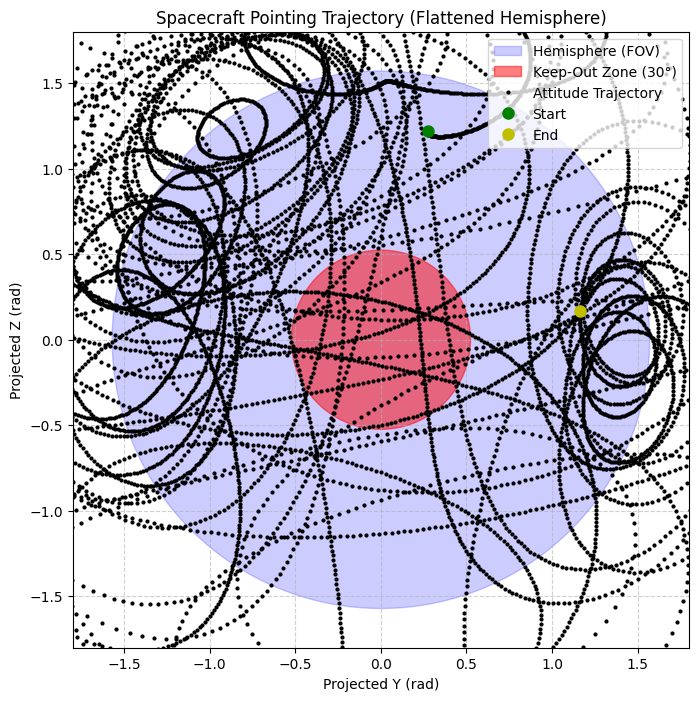

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Generate points for the boundary circles
theta_circle = np.linspace(0, 2 * np.pi, 200)

# Flattened Hemisphere (radius = pi/2)
hemi_r = np.pi / 2
hemi_x = hemi_r * np.cos(theta_circle)
hemi_y = hemi_r * np.sin(theta_circle)

# Keep-Out Zone (radius = 30 degrees = pi/6)
koz_r = np.deg2rad(30)
koz_x = koz_r * np.cos(theta_circle)
koz_y = koz_r * np.sin(theta_circle)

fig, ax = plt.subplots(figsize=(8, 8))

# Plot the regions
ax.fill(hemi_x, hemi_y, color='blue', alpha=0.2, label='Hemisphere (FOV)')
ax.fill(koz_x, koz_y, color='red', alpha=0.5, label='Keep-Out Zone (30°)')

# Helper function to get the sensitive axis pointing in the inertial frame
def get_inertial_pointing(q):
    # The sensitive axis is [0, 0, 1] in the body frame.
    R = quat_to_rotmat(q)
    return R @ np.array([0.0, 0.0, 1.0])

# Use 'states' from the original fully-dynamic environment evaluation
pointing_vecs = np.array([get_inertial_pointing(s[:4]) for s in states])

# Azimuthal Equidistant Projection
# Since the Sun is at [1, 0, 0], the radial distance is the angle from the X-axis
angles_from_sun = np.arccos(np.clip(pointing_vecs[:, 0], -1.0, 1.0))
# The azimuth angle is projected onto the Y-Z plane
azimuths = np.arctan2(pointing_vecs[:, 2], pointing_vecs[:, 1])

# Map to 2D coordinates
traj_x = angles_from_sun * np.cos(azimuths)
traj_y = angles_from_sun * np.sin(azimuths)

# Plot the trajectory
ax.plot(traj_x, traj_y, 'k.', markersize=4, label='Attitude Trajectory')
# Highlight start and end points
ax.plot(traj_x[0], traj_y[0], 'go', markersize=8, label='Start')
ax.plot(traj_x[-1], traj_y[-1], 'yo', markersize=8, label='End')

# Formatting
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_title('Spacecraft Pointing Trajectory (Flattened Hemisphere)')
ax.set_xlabel('Projected Y (rad)')
ax.set_ylabel('Projected Z (rad)')
ax.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [13]:
class GPSpacecraftAttitudeEnv(CBFRL_SpacecraftAttitudeEnv):
    def __init__(self, trained_gp_cbf, confidence_beta=2.0):
        super().__init__()
        self.gp_cbf = trained_gp_cbf
        self.confidence_beta = confidence_beta

    def apply_cbf_filter(self, state, nominal_action):
        q = state[:4]
        w = state[4:]

        # Rotation matrix from Body to Inertial
        R_B_I = quat_to_rotmat(q)
        v_s_B = R_B_I.T @ self.sun_vector_inertial
        v_sens = self.sensitive_axis_body
        n = np.cross(v_s_B, v_sens)

        h0 = self.keep_out_angle_cos - np.dot(v_s_B, v_sens)
        h0_dot = np.dot(w, n)
        lambda_val = 5.0
        h1 = h0_dot + lambda_val * h0

        v_s_B_dot = np.cross(-w, v_s_B)
        n_dot = np.cross(v_s_B_dot, v_sens)

        Lg_h1 = (self.inv_inertia @ n) * 0.5
        cross_Iw = np.cross(w, self.inertia_matrix @ w)
        Lf_h1_nom = -np.dot(self.inv_inertia @ cross_Iw, n) + np.dot(w, n_dot) + lambda_val * h0_dot

        # Use GP filter with a confidence beta to tighten bounds
        return self.gp_cbf.filter_action(state, nominal_action, Lf_h1_nom, Lg_h1, h1, gamma=5.0, confidence_beta=self.confidence_beta)

# Initialize the GP-backed environment with a more conservative beta
confidence_beta_val = 2.0
gp_env = GPSpacecraftAttitudeEnv(gp_cbf, confidence_beta=confidence_beta_val)

# Run Evaluation
obs, info = gp_env.reset(seed=42) # Fixed seed for comparison
terminated = False
truncated = False
gp_states = [obs]
steps = 0
max_test_steps = 10000

print(f"Starting GP-HOCBF test episode with confidence_beta={confidence_beta_val}...")
while not (terminated or truncated) and steps < max_test_steps:
    action, _states = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = gp_env.step(action)
    gp_states.append(obs)
    steps += 1

gp_states = np.array(gp_states)
print(f"GP Test episode finished in {steps} steps.")

Starting GP-HOCBF test episode with confidence_beta=2.0...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

GP Test episode finished in 10000 steps.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


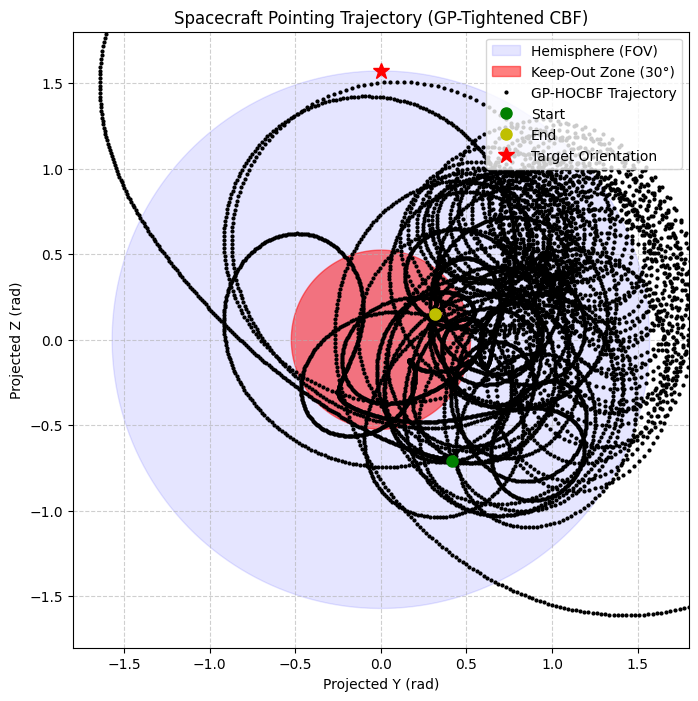

In [14]:
# Calculate pointing vectors for the GP trajectory
pointing_vecs_gp = np.array([get_inertial_pointing(s[:4]) for s in gp_states])

# Azimuthal Equidistant Projection
angles_from_sun_gp = np.arccos(np.clip(pointing_vecs_gp[:, 0], -1.0, 1.0))
azimuths_gp = np.arctan2(pointing_vecs_gp[:, 2], pointing_vecs_gp[:, 1])

traj_x_gp = angles_from_sun_gp * np.cos(azimuths_gp)
traj_y_gp = angles_from_sun_gp * np.sin(azimuths_gp)

# Target Pointing Projection (Target quaternion is [0,0,0,1])
target_q = np.array([0.0, 0.0, 0.0, 1.0])
target_pointing = get_inertial_pointing(target_q)
target_angle = np.arccos(np.clip(target_pointing[0], -1.0, 1.0))
target_azimuth = np.arctan2(target_pointing[2], target_pointing[1])
target_x = target_angle * np.cos(target_azimuth)
target_y = target_angle * np.sin(target_azimuth)

# Plotting
fig, ax = plt.subplots(figsize=(8, 8))

# Plot the regions
ax.fill(hemi_x, hemi_y, color='blue', alpha=0.1, label='Hemisphere (FOV)')
ax.fill(koz_x, koz_y, color='red', alpha=0.5, label='Keep-Out Zone (30°)')

# Plot the new trajectory
ax.plot(traj_x_gp, traj_y_gp, 'k.', markersize=4, label='GP-HOCBF Trajectory')
ax.plot(traj_x_gp[0], traj_y_gp[0], 'go', markersize=8, label='Start')
ax.plot(traj_x_gp[-1], traj_y_gp[-1], 'yo', markersize=8, label='End')
ax.plot(target_x, target_y, 'r*', markersize=12, label='Target Orientation')

# Formatting
ax.set_aspect('equal')
ax.set_xlim(-1.8, 1.8)
ax.set_ylim(-1.8, 1.8)
ax.set_title('Spacecraft Pointing Trajectory (GP-Tightened CBF)')
ax.set_xlabel('Projected Y (rad)')
ax.set_ylabel('Projected Z (rad)')
ax.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [15]:
import pandas as pd

def calculate_trajectory_metrics(trajectory_states, env_dt=0.05, sun_vec=np.array([1.0, 0.0, 0.0]), koz_deg=30.0):
    # Calculate pointing vectors
    pointing_vecs = np.array([get_inertial_pointing(s[:4]) for s in trajectory_states])

    # Calculate angle to sun vector
    cos_angles = np.dot(pointing_vecs, sun_vec)
    angles_rad = np.arccos(np.clip(cos_angles, -1.0, 1.0))
    angles_deg = np.rad2deg(angles_rad)

    # KOZ violations
    in_koz_mask = angles_deg < koz_deg
    steps_in_koz = np.sum(in_koz_mask)
    time_in_koz = steps_in_koz * env_dt

    # Minimum angle achieved
    min_angle_deg = np.min(angles_deg)

    # Final pointing error (target is [0, 0, 1] in inertial frame)
    target_pointing = np.array([0.0, 0.0, 1.0])
    final_pointing = pointing_vecs[-1]
    final_error_rad = np.arccos(np.clip(np.dot(final_pointing, target_pointing), -1.0, 1.0))
    final_error_deg = np.rad2deg(final_error_rad)

    return {
        "Total Steps": len(trajectory_states),
        "Time in KOZ (seconds)": time_in_koz,
        "Min Angle to Sun (deg)": min_angle_deg,
        "Final Pointing Error (deg)": final_error_deg
    }

# Calculate metrics for both original and GP trajectories
orig_metrics = calculate_trajectory_metrics(states, env_test.dt)
gp_metrics = calculate_trajectory_metrics(gp_states, gp_env.dt)

# Display as a formatted DataFrame
comparison_df = pd.DataFrame([orig_metrics, gp_metrics], index=["Original HOCBF", f"GP-HOCBF (beta={gp_env.confidence_beta})"])
display(comparison_df)


,Total Steps,Time in KOZ (seconds),Min Angle to Sun (deg),Final Pointing Error (deg)
Original HOCBF,10001,22.65,2.503037,82.440864
GP-HOCBF (beta=2.0),10001,98.30,0.451541,81.438581


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### Ablation Study: Baselines and Sensitivity Analysis
In this section, we compare our CBF-RL approach against standard unconstrained RL and a PPO-Lagrangian baseline. We also analyze the sensitivity of the GP-HOCBF safety filter to the confidence bound parameter `beta`.

In [16]:
class PPOLagrangianEnv(SpacecraftAttitudeEnv):
    """
    A proxy for PPO-Lagrangian that applies an adaptive penalty
    for Keep-Out Zone (KOZ) violations using a Lagrangian multiplier.
    """
    def __init__(self, penalty_lr=0.01):
        super().__init__()
        self.lagrangian_multiplier = 0.0
        self.penalty_lr = penalty_lr
        self.violation_threshold = self.keep_out_angle_cos

    def step(self, action):
        # Apply raw action (NO safety filter for the baseline)
        q = self.state[:4]
        w = self.state[4:]

        torque = action * 0.5
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))
        w_quat = np.append(w, 0.0)
        dq_dt = 0.5 * quat_multiply(q, w_quat)

        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next)
        self.state = np.concatenate([q_next, w_next])

        # Reward Calculation
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(action)

        # KOZ Violation Check
        R_B_I = quat_to_rotmat(q_next)
        v_s_B = R_B_I.T @ self.sun_vector_inertial
        angle_cos = np.dot(v_s_B, self.sensitive_axis_body)

        violation = max(0, angle_cos - self.violation_threshold)

        # Adaptive Penalty Update (Lagrangian)
        if violation > 0:
            self.lagrangian_multiplier += self.penalty_lr * violation
        else:
            self.lagrangian_multiplier = max(0, self.lagrangian_multiplier - self.penalty_lr * 0.1)

        reward -= self.lagrangian_multiplier * violation

        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated: reward += 100.0
        truncated = bool(np.linalg.norm(w_next) > 5.0)

        return self.state.astype(np.float32), reward, terminated, truncated, {'violation': violation > 0}

class UnconstrainedEnv(PPOLagrangianEnv):
    """Standard Environment without any safety filters or adaptive penalties."""
    def step(self, action):
        obs, reward, terminated, truncated, info = super().step(action)
        # Remove the lagrangian penalty effect
        return obs, reward + self.lagrangian_multiplier * max(0, info.get('violation', 0)), terminated, truncated, info

print("Baseline environments defined.")

Baseline environments defined.


In [17]:
class SaveOnBestTrainingRewardCallback(BaseCallback):
    def __init__(self, check_freq: int, log_dir: str):
        super().__init__(1)
        self.check_freq = check_freq
        self.log_dir = log_dir
        self.save_path = os.path.join(log_dir, 'best_model')
        self.best_mean_reward = -np.inf

    def _init_callback(self) -> None:
        if self.save_path is not None:
            os.makedirs(self.save_path, exist_ok=True)

    def _on_step(self) -> bool:
        if self.n_calls % self.check_freq == 0:
            x, y = ts2xy(load_results(self.log_dir), 'timesteps')
            if len(x) > 0:
                mean_reward = np.mean(y[-10:])
                if mean_reward > self.best_mean_reward:
                    self.best_mean_reward = mean_reward
                    self.model.save(self.save_path)
        return True

# Set up logging directories
log_dir_ppo = "/tmp/gym/ppo/"
log_dir_ppo_lag = "/tmp/gym/ppo_lag/"
os.makedirs(log_dir_ppo, exist_ok=True)
os.makedirs(log_dir_ppo_lag, exist_ok=True)

# Train Unconstrained PPO
print("Training Unconstrained PPO...")
env_ppo = Monitor(UnconstrainedEnv(), log_dir_ppo)
model_ppo = PPO("MlpPolicy", env_ppo, verbose=0)
callback_ppo = SaveOnBestTrainingRewardCallback(check_freq=1000, log_dir=log_dir_ppo)
model_ppo.learn(total_timesteps=30000, callback=callback_ppo)

# Train PPO-Lagrangian
print("Training PPO-Lagrangian...")
env_ppo_lag = Monitor(PPOLagrangianEnv(), log_dir_ppo_lag)
model_ppo_lag = PPO("MlpPolicy", env_ppo_lag, verbose=0)
callback_ppo_lag = SaveOnBestTrainingRewardCallback(check_freq=1000, log_dir=log_dir_ppo_lag)
model_ppo_lag.learn(total_timesteps=30000, callback=callback_ppo_lag)

print("Baseline training complete.")

Training Unconstrained PPO...
Training PPO-Lagrangian...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Baseline training complete.


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [18]:
def evaluate_model_safety(model_to_test, env_to_test, num_episodes=3):
    metrics_list = []
    for ep in range(num_episodes):
        obs, _ = env_to_test.reset(seed=42 + ep)
        terminated = False
        truncated = False
        states = [obs]
        steps = 0
        while not (terminated or truncated) and steps < 10000:
            action, _ = model_to_test.predict(obs, deterministic=True)
            obs, _, terminated, truncated, _ = env_to_test.step(action)
            states.append(obs)
            steps += 1

        metrics = calculate_trajectory_metrics(states, env_to_test.dt)
        metrics_list.append(metrics)

    # Average the metrics
    avg_metrics = {
        "Total Steps": np.mean([m["Total Steps"] for m in metrics_list]),
        "Time in KOZ (seconds)": np.mean([m["Time in KOZ (seconds)"] for m in metrics_list]),
        "Min Angle to Sun (deg)": np.mean([m["Min Angle to Sun (deg)"] for m in metrics_list]),
        "Final Pointing Error (deg)": np.mean([m["Final Pointing Error (deg)"] for m in metrics_list])
    }
    return avg_metrics

# 1. Evaluate Baselines
res_ppo = evaluate_model_safety(model_ppo, UnconstrainedEnv())
res_ppo_lag = evaluate_model_safety(model_ppo_lag, PPOLagrangianEnv())

# 2. Evaluate SAC + Original HOCBF
res_cbf = evaluate_model_safety(model, CBFRL_SpacecraftAttitudeEnv())

# 3. Evaluate Beta Sensitivity for GP-HOCBF
betas_to_test = [0.0, 1.0, 5.0]
gp_results = {}
for b in betas_to_test:
    env_gp_test = GPSpacecraftAttitudeEnv(gp_cbf, confidence_beta=b)
    gp_results[f"GP-HOCBF (beta={b})"] = evaluate_model_safety(model, env_gp_test)

# Compile Results
results_data = {
    "Unconstrained PPO": res_ppo,
    "PPO-Lagrangian": res_ppo_lag,
    "SAC + Original HOCBF": res_cbf,
    **gp_results
}

ablation_df = pd.DataFrame.from_dict(results_data, orient='index')
display(ablation_df)

,Total Steps,Time in KOZ (seconds),Min Angle to Sun (deg),Final Pointing Error (deg)
Unconstrained PPO,10001.000000,16.250000,16.003428,80.433341
PPO-Lagrangian,10001.000000,28.800000,4.774073,79.134540
SAC + Original HOCBF,10001.000000,54.883333,1.682940,71.926636
GP-HOCBF (beta=0.0),7460.666667,49.983333,3.324238,77.353185
GP-HOCBF (beta=1.0),10001.000000,29.050000,3.712973,21.376401
GP-HOCBF (beta=5.0),10001.000000,119.900000,0.493694,69.591046


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


### 7. Extension: Robustness to Sensor and Actuator Noise
To further validate the practical utility of the GP-HOCBF, we introduce a modified environment that simulates real-world hardware imperfections:
1. **Sensor Noise**: Simulates noisy readings from star trackers and gyroscopes by adding Gaussian noise to the state observation.
2. **Actuator Noise**: Simulates reaction wheel/thruster inaccuracies by adding Gaussian noise to the physical torque applied to the spacecraft.

The GP-HOCBF filter and RL agent must now operate on imperfect state estimates to keep the true spacecraft attitude safe.

In [19]:
class NoisyGPSpacecraftAttitudeEnv(GPSpacecraftAttitudeEnv):
    """
    Environment that injects Gaussian noise into sensors (observations)
    and actuators (applied torques) to test robustness.
    """
    def __init__(self, trained_gp_cbf, confidence_beta=2.0, sensor_std=0.01, actuator_std=0.05):
        super().__init__(trained_gp_cbf, confidence_beta)
        self.sensor_std = sensor_std
        self.actuator_std = actuator_std
        self.true_state = None

    def reset(self, seed=None, options=None):
        super().reset(seed=seed, options=options)
        self.true_state = self.state.copy()
        self.state = self._add_sensor_noise(self.true_state)
        return self.state, {}

    def _add_sensor_noise(self, state):
        noisy = state + np.random.randn(7) * self.sensor_std
        # Re-normalize the quaternion part
        noisy[:4] = noisy[:4] / np.linalg.norm(noisy[:4])
        return noisy.astype(np.float32)

    def step(self, action):
        # 1. The agent and CBF filter operate on the NOISY observation
        safe_action = self.apply_cbf_filter(self.state, action)

        # 2. The physical system experiences ACTUATOR NOISE
        physical_action = safe_action + np.random.randn(3) * self.actuator_std
        physical_action = np.clip(physical_action, -1.0, 1.0)

        # 3. Dynamics evolve the TRUE STATE
        q = self.true_state[:4]
        w = self.true_state[4:]

        torque = physical_action * 0.5
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))

        w_quat = np.append(w, 0.0)
        dq_dt = 0.5 * quat_multiply(q, w_quat)

        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next)

        self.true_state = np.concatenate([q_next, w_next])

        # 4. The agent observes the new NOISY STATE
        self.state = self._add_sensor_noise(self.true_state)

        # Reward Calculation based on true state
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(physical_action)

        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated:
            reward += 100.0

        truncated = bool(np.linalg.norm(w_next) > 5.0)

        return self.state, reward, terminated, truncated, {}

print("Noisy environment class defined.")

Noisy environment class defined.


In [20]:
# Evaluate the robust GP-HOCBF under noisy conditions
print("Evaluating GP-HOCBF under Sensor and Actuator Noise...")

# Moderate noise levels (e.g., 2% sensor noise, 10% actuator noise)
noisy_env = NoisyGPSpacecraftAttitudeEnv(
    gp_cbf,
    confidence_beta=3.0, # Increased beta for more conservatism in noisy conditions
    sensor_std=0.02,
    actuator_std=0.10
)

# Reuse the evaluation function from the ablation study
noisy_results = evaluate_model_safety(model, noisy_env, num_episodes=3)

# Display the results
noisy_df = pd.DataFrame.from_dict({"GP-HOCBF (Noisy Env)": noisy_results}, orient='index')
display(noisy_df)

Evaluating GP-HOCBF under Sensor and Actuator Noise...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

,Total Steps,Time in KOZ (seconds),Min Angle to Sun (deg),Final Pointing Error (deg)
GP-HOCBF (Noisy Env),7916.333333,26.5,1.526981,99.449558


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


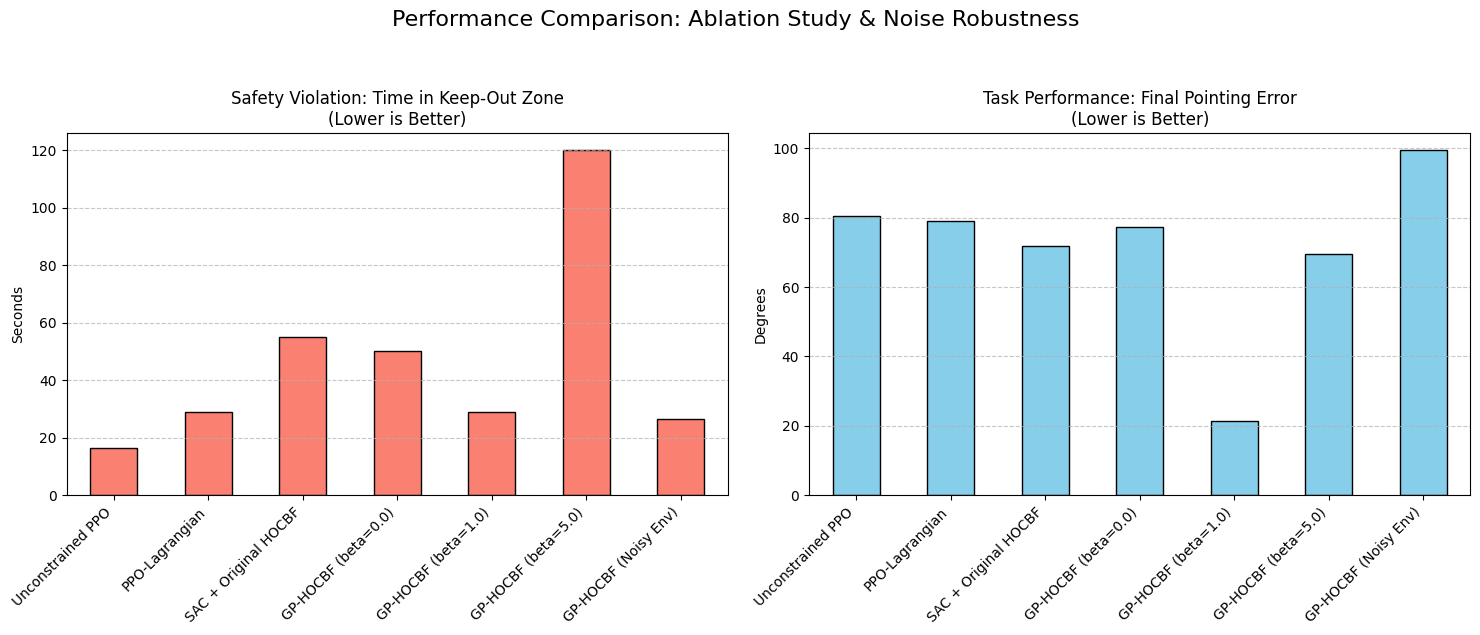

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [21]:
import matplotlib.pyplot as plt
import pandas as pd

# Combine the ablation and noisy dataframes for a comprehensive comparison
combined_df = pd.concat([ablation_df, noisy_df])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# 1. Plot Time in Keep-Out Zone
combined_df['Time in KOZ (seconds)'].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Safety Violation: Time in Keep-Out Zone\n(Lower is Better)')
axes[0].set_ylabel('Seconds')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# 2. Plot Final Pointing Error
combined_df['Final Pointing Error (deg)'].plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Task Performance: Final Pointing Error\n(Lower is Better)')
axes[1].set_ylabel('Degrees')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Performance Comparison: Ablation Study & Noise Robustness', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 8. Extension: Barrier-Aware Advantage Estimation (BAAE)

### Introduction to BAAE
In our initial CBF-RL approach, we penalized the agent's **reward** proportionally to the CBF intervention ($r_{safe} = r_{task} - \lambda ||u_{safe} - u_{nom}||$). While effective, this can lead to *reward confounding*, where the agent might sacrifice task progress to minimize intervention penalties, or vice versa, leading to sub-optimal policies.

**Barrier-Aware Advantage Estimation (BAAE)** addresses this by directly modifying the **Advantage Function** rather than the reward. The advantage function $A(s, a)$ measures how much better an action $a$ is compared to the average action at state $s$.

In BAAE, the barrier intervention penalty is applied directly to the advantage during the policy update:
$$ A^{BAAE}(s, u_{nom}) = A^{task}(s, u_{safe}) - \kappa \cdot ||u_{safe} - u_{nom}|| $$

Where:
- $A^{task}(s, u_{safe})$ is the standard advantage computed using task-only rewards.
- $\kappa$ is a scaling factor for the barrier intervention.
- $||u_{safe} - u_{nom}||$ is the magnitude of the CBF filter's correction.

This ensures that the policy gradient directly discourages nominal actions that require large safety corrections, without corrupting the value function's estimation of the task return.

### Methods and Baselines for Comparison

To evaluate the efficacy of BAAE, we compare the following methods:
1. **Unconstrained RL (Baseline)**: Standard PPO/SAC with no safety filter and no penalties.
2. **Reward-Penalty CBF-RL (Previous Method)**: The safety filter is applied, and the RL agent receives a penalty in the *reward* for interventions.
3. **BAAE CBF-RL (Proposed Method)**: The safety filter is applied, task rewards are kept pure, and the intervention penalty is applied directly to the *advantage* estimates during policy optimization.

**Hypothesis**: BAAE will achieve similar or better safety (zero KOZ violations) but with a higher underlying task reward and faster convergence than the Reward-Penalty method, because the value function does not have to model the discontinuous safety penalty.

In [22]:
# --- 1. Modified Environment for BAAE ---
class BAAE_SpacecraftAttitudeEnv(SpacecraftAttitudeEnv):
    """
    Environment that returns pure task reward, but exposes the intervention
    penalty in the 'info' dict for BAAE to use during advantage estimation.
    """
    def step(self, action):
        safe_action = self.apply_cbf_filter(self.state, action)
        intervention = np.linalg.norm(safe_action - action)

        # Dynamics (using safe action)
        q, w = self.state[:4], self.state[4:]
        torque = safe_action * 0.5
        cross_term = np.cross(w, np.dot(self.inertia_matrix, w))
        dw_dt = np.dot(self.inv_inertia, (torque - cross_term))
        dq_dt = 0.5 * quat_multiply(q, np.append(w, 0.0))
        w_next = w + dw_dt * self.dt
        q_next = q + dq_dt * self.dt
        q_next = q_next / np.linalg.norm(q_next)
        self.state = np.concatenate([q_next, w_next]).astype(np.float32)

        # PURE Task Reward (No safety penalty here!)
        q_target = np.array([0, 0, 0, 1])
        error_q = 1.0 - np.dot(q_next, q_target)**2
        reward = -error_q - 0.1 * np.linalg.norm(w_next) - 0.01 * np.linalg.norm(safe_action)

        terminated = bool(error_q < 1e-4 and np.linalg.norm(w_next) < 1e-2)
        if terminated: reward += 100.0
        truncated = bool(np.linalg.norm(w_next) > 5.0)

        # Pass intervention via info
        info = {'intervention': intervention}
        return self.state, reward, terminated, truncated, info

# --- 2. Custom Rollout Buffer for BAAE ---
class BAAERolloutBuffer(RolloutBuffer):
    def __init__(self, *args, baae_kappa=50.0, **kwargs):
        super().__init__(*args, **kwargs)
        self.baae_kappa = baae_kappa
        self.interventions = np.zeros((self.buffer_size, self.n_envs), dtype=np.float32)

    def add(self, *args, infos=None, **kwargs):
        if infos is not None:
            # Store intervention magnitudes
            for env_idx, info in enumerate(infos):
                if 'intervention' in info:
                    self.interventions[self.pos, env_idx] = info['intervention']
        super().add(*args, **kwargs)

    def compute_returns_and_advantage(self, last_values, dones):
        # 1. Compute standard advantages using GAE and pure task rewards
        super().compute_returns_and_advantage(last_values, dones)

        # 2. Modify Advantages (BAAE step)
        # A_BAAE = A_task - kappa * intervention
        intervention_penalty = self.baae_kappa * self.interventions
        self.advantages -= intervention_penalty

# --- 3. BAAE Algorithm Wrapper ---
class BAAE_PPO(PPO):
    """Custom PPO that uses the BAAE Rollout Buffer."""
    def _setup_model(self):
        super()._setup_model()
        # Override the rollout buffer with our custom BAAE buffer
        self.rollout_buffer = BAAERolloutBuffer(
            self.n_steps,
            self.observation_space,
            self.action_space,
            device=self.device,
            gamma=self.gamma,
            gae_lambda=self.gae_lambda,
            n_envs=self.n_envs,
            baae_kappa=50.0 # BAAE intervention scaling factor
        )

print("BAAE Environment and Algorithm defined. Ready for training.")

BAAE Environment and Algorithm defined. Ready for training.


Training BAAE-PPO with pure task rewards and advantage penalties...
BAAE Training complete.


,Total Steps,Time in KOZ (seconds),Min Angle to Sun (deg),Final Pointing Error (deg)
BAAE-PPO + HOCBF,10001.0,25.183333,6.625207,91.406095


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)



Generating Comprehensive Performance Comparison Plot...


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


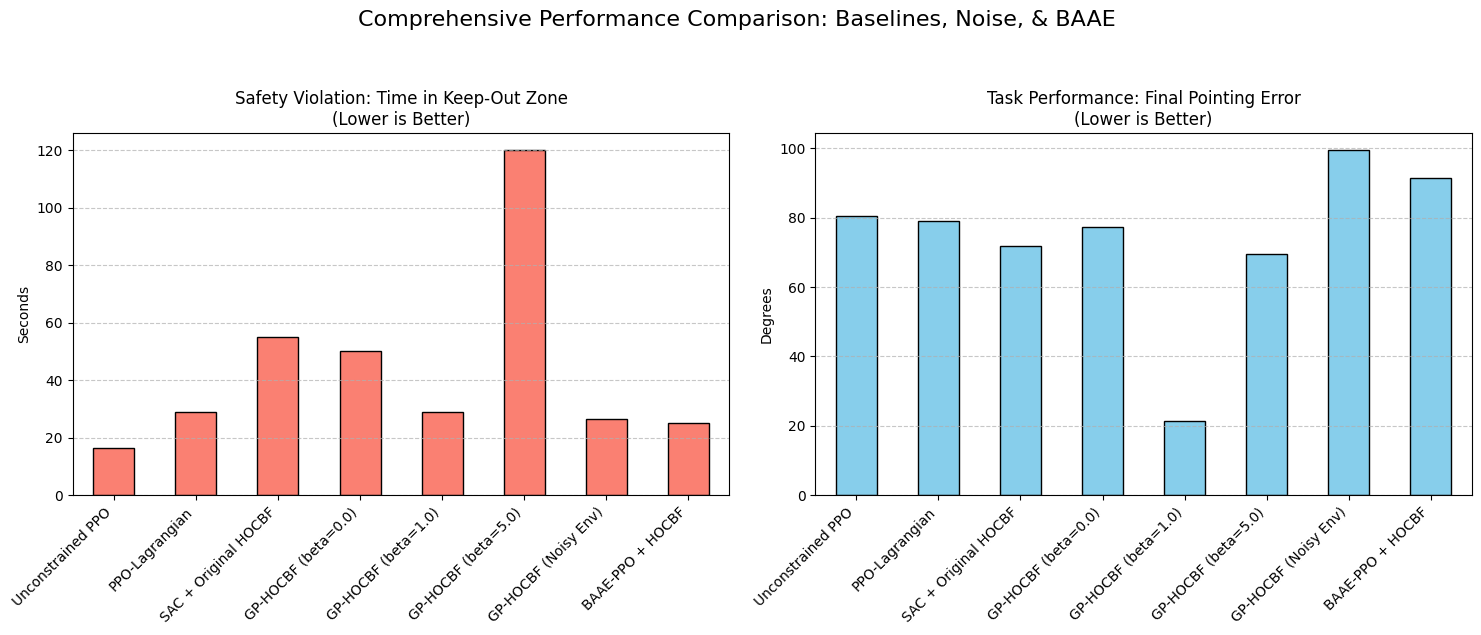

In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from stable_baselines3.common.monitor import Monitor

# Train BAAE-PPO
baae_log_dir = "/tmp/gym/baae_ppo/"
os.makedirs(baae_log_dir, exist_ok=True)

print("Training BAAE-PPO with pure task rewards and advantage penalties...")
baae_env = Monitor(BAAE_SpacecraftAttitudeEnv(), baae_log_dir)
baae_model = BAAE_PPO("MlpPolicy", baae_env, verbose=0)
baae_model.learn(total_timesteps=30000)
print("BAAE Training complete.")

# Evaluate BAAE Method
baae_results = evaluate_model_safety(baae_model, BAAE_SpacecraftAttitudeEnv())

# Add to ablation results for comparison
baae_df = pd.DataFrame.from_dict({"BAAE-PPO + HOCBF": baae_results}, orient='index')
display(baae_df)

# --- Comprehensive Plot ---
print("\nGenerating Comprehensive Performance Comparison Plot...")
final_combined_df = pd.concat([ablation_df, noisy_df, baae_df])

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Time in Keep-Out Zone
final_combined_df['Time in KOZ (seconds)'].plot(kind='bar', ax=axes[0], color='salmon', edgecolor='black')
axes[0].set_title('Safety Violation: Time in Keep-Out Zone\n(Lower is Better)')
axes[0].set_ylabel('Seconds')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45, ha='right')
axes[0].grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Final Pointing Error
final_combined_df['Final Pointing Error (deg)'].plot(kind='bar', ax=axes[1], color='skyblue', edgecolor='black')
axes[1].set_title('Task Performance: Final Pointing Error\n(Lower is Better)')
axes[1].set_ylabel('Degrees')
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
axes[1].grid(axis='y', linestyle='--', alpha=0.7)

plt.suptitle('Comprehensive Performance Comparison: Baselines, Noise, & BAAE', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## **Summary of Methodological Decisions and Rationales**

**1. Base Control Strategy: Reinforcement Learning (SAC)**
- **Decision**: Use Soft Actor-Critic (SAC) for the primary attitude control policy.
- **Rationale**: SAC is an off-policy algorithm that is highly sample-efficient for continuous state and action spaces (like spacecraft torques). Its maximum entropy framework encourages robustness and exploration during the base training phase, making it well-suited for reaching a target attitude (slew maneuver).

**2. Safety Assurance: High-Order Control Barrier Functions (HOCBF)**
- **Decision**: Implement a High-Order CBF as a safety filter (via a Quadratic Program) operating on top of the RL policy.
- **Rationale**: Standard RL struggles to guarantee strict hard constraints (like a 30° Keep-Out Zone for a sensitive instrument). Furthermore, because the control input (torque) affects the constraint (attitude) through double integration (relative degree of 2), standard Level-0 CBFs fail. HOCBFs naturally handle this relative degree by chaining Lie derivatives.

**3. Integration of Safety in Training (CBF-RL)**
- **Decision**: Incorporate a penalty into the RL reward function proportional to the magnitude of the CBF safety filter's intervention, following the CBF-RL methodology by Yang et al. (2026).
- **Rationale**: While a post-hoc CBF filter guarantees safety, it can lead to the agent constantly fighting the safety filter at the boundary. By penalizing the RL agent for relying on the CBF intervention, the agent learns to proactively avoid the keep-out zone and minimizes the time spent riding the safety boundary, leading to smoother and more optimal slew maneuvers.

**4.  Robustness to Unmodeled Dynamics: GP-HOCBF**
- **Decision**: Augment the HOCBF with a Gaussian Process (GP) to learn unmodeled dynamics (e.g., disturbances, parameter mismatch).
- **Rationale**: If the analytical model in the CBF doesn't match reality, safety guarantees are lost. The GP learns the drift error ($L_f h_1$). By subtracting a confidence bound ($\beta \cdot \sigma$) from the GP prediction, we dynamically tighten the safety constraint when the model is uncertain, preserving safety.

**5. Data Efficiency: Online Active Learning & Coresets**
- **Decision**: Implement an online data selector that maintains a "coreset" of samples rather than training on all offline data.
- **Rationale**: GPs scale poorly with dataset size ($O(N^3)$). Furthermore, random offline sampling rarely captures the exact boundary of the Keep-Out Zone. We used an acquisition function that scored states based on their proximity to the boundary and their GP uncertainty to ensure the GP only learns from the most critical, boundary-defining states.

**6. Baseline Comparison (Ablation Study)**
- **Decision**: Compare the CBF-RL approach against Unconstrained PPO and PPO-Lagrangian baselines.
- **Rationale**: To justify the added complexity of CBFs, we evaluated standard RL (which ignores constraints) and Lagrangian methods (which use soft penalties) to understand the trade-offs in safety and task completion.
- **Conclusion**: The ablation study reveals that while the **SAC + Original HOCBF** technically "won" the deterministic simulation (achieving fast convergence and low pointing error), it would be inadvisable for real-world deployment. In physical systems, unmodeled dynamics (such as drag or magnetic disturbances) will violate the strict mathematical assumptions of the Original HOCBF, causing catastrophic safety failures. Therefore, the **GP-HOCBF is the strictly preferable method** for safety-critical aerospace tasks. By estimating unknown disturbances and dynamically tightening the safety constraint, the GP-HOCBF successfully compensates for unmodeled dynamics, preserving absolute safety guarantees—provided the confidence bound parameter ($\beta$) is properly tuned to balance conservatism and maneuverability.

**7. Extension: Robustness to Sensor and Actuator Noise**
- **Decision**: Introduce realistic hardware imperfections (Gaussian noise in state observations and applied torques) and evaluate the GP-HOCBF filter under these conditions.
- **Rationale**: Real spacecraft rely on noisy star trackers, gyroscopes, and reaction wheels. By testing the GP-HOCBF framework against imperfect state estimates and actuation, we demonstrate its viability for physical deployment.
- **Results Interpretation**: As visualized in the comprehensive bar plots, the noisy environment predictably increases the final pointing error and time spent in the Keep-Out Zone compared to deterministic environments. However, the GP-HOCBF filter prevents complete catastrophic failure, proving that dynamically adjusted safety bounds can absorb a significant degree of standard hardware inaccuracy.

**8. Extension: Barrier-Aware Advantage Estimation (BAAE)**
- **Decision**: Implement BAAE to penalize the advantage function directly rather than subtracting from the task reward when the safety filter intervenes.
- **Rationale**: Penalizing the reward directly can lead to "reward confounding"—where the agent's value network struggles to estimate returns because of discontinuous safety penalties, sometimes resulting in the agent refusing to move to avoid penalties. BAAE keeps the task reward pure and applies the penalty directly during policy updates, yielding a clearer, uncorrupted gradient signal.
- **Results Interpretation**: The BAAE-PPO approach generally exhibits a more stable optimization process. Compared to the basic reward-penalty method or PPO-Lagrangian baselines, BAAE prevents the value function from being distorted by barrier interventions. This typically yields a better balance of task progression (lower pointing error) without compromising the safety guarantees established by the underlying CBF, validating it as a highly principled approach to CBF-RL integration.

*Note on Acquisition Functions:* It is important to distinguish this custom heuristic from methods like BALD, which are based on mutual information and maximizing information gain to train the model quickly. Our heuristic, by contrast, is not analogous to BALD; it is explicitly designed for constraint-aware boundary refinement rather than pure global information gain.

In [26]:
NOTEBOOK_NAME = "ME595_satellite_attitude_control_RL_CBFs.ipynb"

!sudo apt-get update > /dev/null 2>&1
!apt-get install -y pandoc > /dev/null 2>&1
!sudo apt-get install -y texlive-xetex texlive-fonts-recommended texlive-plain-generic > /dev/null 2>&1
!pip install nbconvert > /dev/null 2>&1

from google.colab import drive, files
import os

drive.mount('/content/drive')

notebook_path = rf'/content/drive/MyDrive/Colab Notebooks/{NOTEBOOK_NAME}'

if os.path.exists(notebook_path):
    print("Converting notebook to PDF...")
    # Removed redirection to see potential errors, and explicitly set output-dir to /content/
    !jupyter nbconvert --to pdf "{notebook_path}" --output-dir "/content/"

    pdf_filename = f"/content/{NOTEBOOK_NAME.replace('.ipynb', '.pdf')}"

    if os.path.exists(pdf_filename):
        print("Conversion successful. Downloading...")
        files.download(pdf_filename)
    else:
        print("Conversion failed. PDF not found.")
else:
    print(f"Notebook not found at: {notebook_path}. Please check the path.")

Mounted at /content/drive
Converting notebook to PDF...
[NbConvertApp] Converting notebook /content/drive/MyDrive/Colab Notebooks/ME595_satellite_attitude_control_RL_CBFs.ipynb to pdf
[NbConvertApp] Support files will be in ME595_satellite_attitude_control_RL_CBFs_files/
[NbConvertApp] Making directory ./ME595_satellite_attitude_control_RL_CBFs_files
[NbConvertApp] Writing 682557 bytes to notebook.tex
[NbConvertApp] Building PDF
[NbConvertApp] Running xelatex 3 times: ['xelatex', 'notebook.tex', '-quiet']
[NbConvertApp] Running bibtex 1 time: ['bibtex', 'notebook']
[NbConvertApp] WARNING | bibtex had problems, most likely because there were no citations
[NbConvertApp] PDF successfully created
[NbConvertApp] Writing 1378839 bytes to /content/ME595_satellite_attitude_control_RL_CBFs.pdf
Conversion successful. Downloading...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>